# __Feature Engineering__

Our case study is about transforming  __E-waste__, to be a reliable source of critical materials needed for __Electro-mobility__, all enabled by __technology__.


In [16]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


__import pandas as pd__- allows one to load datasets, filter rows and group data. pd is an alias for pandas. pandas handles dataframes so that python can understand data manipulation.
<br>__import numpy as np__- Numpy manages columns and rows as it performs calculations, flags missing values and generates random numbers.<br>
__import matplotlib.pyplot as plt__- pyplot transforms dataframes into visual cahrts to identify patterns and trends

In [17]:
df_titanic = pd.read_csv('Titanic.csv')

_This loads the titanic datasets file. df_titanic is a variable that reads the csv file and organizes the data into rows and columns._

In [18]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


_The line displays the first 5 rows of the titanic datasets for inspecting._

In [19]:
file_name = glob.glob("Titanic_Ages*")[0]
df_ages = pd.read_csv(file_name)

_First line finds the path for the file in the computer_
<br>_Second line opens and reads the file_

In [20]:
df_ages.head()

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


_This line displays the first 5 rows of the titanic ages file_

In [21]:
age_lookup = df_ages.set_index('Name')['Age']


_This line creates pandas series to map passenger names to their ages._

In [22]:
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))


_This line fills missing 'Age' values by looking up an estimated age based on the passenger's 'Name'_

In [23]:
df_titanic[df_titanic['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.05,NaN,S


_The line filters and displays the rows where Age column is NaN_

In [24]:
df_titanic.loc[df_titanic['Name'].str.contains('Peduzzi'), 'Age'] = 24


_This line manually fixes for a passenger's age by looking for thier last name and assigning age 24_

In [25]:
df_titanic[df_titanic['Name'].str.contains('Peduzzi')]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,24.0,0,0,A/5 2817,8.05,NaN,S


_This line filters and displays the data row for a passenger called Peduzzi_

In [27]:
mask = df_titanic['Name'].str.contains('pooo', na=False) 
df_titanic.loc[mask, 'Age'] = 24

___df_titanic.head(5)__- it give the first 5 rows of the Titanic dataset so that one can confirm that data was loaded correctly._

In [28]:
df_titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


_This line displays a summary of the dataset's structure, column names, memory usage and missing values._

In [29]:
x=df_titanic.drop(['Cabin','Survived'],axis=1)

_The line removes the columns for Cabin and Survived and saves the rest of the columns into a variable __x__ since they are unhelpful.this separates the features from the targets._

In [30]:
y=df_titanic['Survived']

_Survived column is assigned the variable y which is what the model will learn how to predict._

In [31]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


_This extracts the first 5 rows of __x__ variable so that one can see if Cabin and Survived columns were actually removed._

In [32]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

_The line displays the first 5 entries of the target variable y to confirm the model's responses._

In [33]:
x['Age']=x['Age'].fillna(x['Age'].median())

_The line finds remaining missing values for age and fills them with the median of all ages._

In [34]:
x['Fare']=x['Fare'].fillna(x['Fare'].median())

_The line finds missing values for fare and fills them with the median of all ticket prices._

In [35]:
x['Embarked']=x['Embarked'].fillna(x['Embarked'].mode()[0])

_The line finds any missing values for embarked and fills them with the most common embarking port._

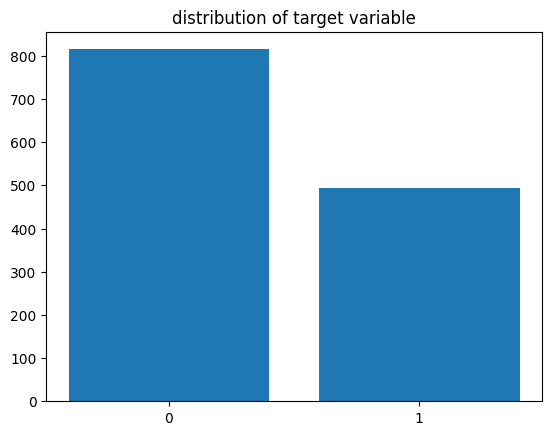

In [36]:
x_plot=y.value_counts()
plt.bar(x_plot.index,x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

_This block counts how many passengers survived or perished, creating a bar chart for visualization._

In [37]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
_The line imports LabelEncoder from Scikit-Learn library so as to convert text into numerals._

In [38]:
X = df_titanic.drop(columns=['Survived'])


_The line creates dataset X by dropping column 'Survived'_

In [39]:
train=pd.DataFrame()
label=LabelEncoder()
for c in X.columns:
    if(X[c].dtype=='object'):
        train[c]=label.fit_transform(X[c])
    else:
        train[c]=X[c]

_The block creates a new dataset by looping through all columns, converting text into numbers and copies the columns while unchanged._

In [40]:
train.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,155,1,22.0,1,0,720,7.2500,186,2
1,2,1,286,0,38.0,1,0,816,71.2833,106,0
2,3,3,523,0,26.0,0,0,914,7.9250,186,2
3,4,1,422,0,35.0,1,0,65,53.1000,70,2
4,5,3,22,1,35.0,0,0,649,8.0500,186,2


_The line displays the first 5 rows of the file._

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

_The block imports all algorithms, validation tools and evaluation metrics._

In [43]:
def logistic(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
    lr = LogisticRegression(max_iter=2000) 
    lr.fit(X_train, y_train)
    y_pre = lr.predict(X_test)
    print('Accuracy : ', accuracy_score(y_test, y_pre))


_The function splits data into training and testing sets, trains the logistic regression model, predicts survival on the test set and prints overall accuracy on classification._

In [ ]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Fare'] = train['Fare'].fillna(train['Fare'].median())


_The lines find missingvalues in age and fare columns on the train dataset and fills with respective median values._

In [45]:
logistic(train,y)

Accuracy :  0.8473282442748091


_The line passes train and y answers into the logistic function._

In [46]:
print(train.isna().sum())


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


_The line calculates and displays missing values in every column of the train dataset._

In [ ]:
import glob
import pandas as pd

file_name = glob.glob("Titanic_Ages*")[0]
df_ages = pd.read_csv(file_name)
df_ages.head()


_The block finds the titanic file, loads it into pandas dataframe and displays the first 5 rows._

In [ ]:
from sklearn.preprocessing import OneHotEncoder

_The line imports OneHotEncoder from Scikit-Learn library to convert text into numerals._

In [49]:
train2 = pd.DataFrame()
columns_to_encode = ['Sex', 'Embarked']

for c in x.columns:
    if c in columns_to_encode:
        ohe_cols = pd.get_dummies(x[c], prefix=c, dtype=np.int8)
        train2 = pd.concat([train2, ohe_cols], axis=1)
    elif x[c].dtype == 'object':
        train2[c] = label.fit_transform(x[c])
    else:
        train2[c] = x[c]


This code creates a new dataset by One-Hot Encoding specific categorical columns (Sex, Embarked) and Label Encoding all remaining text features, while copying numerical data over completely unchanged.

In [50]:
train2.head()

,PassengerId,Pclass,Name,Sex_female,Sex_male,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,3,155,0,1,22.0,1,0,720,7.2500,0,0,1
1,2,1,286,1,0,38.0,1,0,816,71.2833,1,0,0
2,3,3,523,1,0,26.0,0,0,914,7.9250,0,0,1
3,4,1,422,1,0,35.0,1,0,65,53.1000,0,0,1
4,5,3,22,0,1,35.0,0,0,649,8.0500,0,0,1


In [ ]:
_The line displays the first 5 rows of the new dataset._

In [52]:
def logistic(x, y):
    x_train2, x_test, y_train2, y_test = train_test_split(x, y, random_state=42, test_size=0.2)
    lr = LogisticRegression()
    lr.fit(x_train2, y_train2)
    y_pre = lr.predict(x_test)
    print('Accuracy : ', accuracy_score(y_test, y_pre))


_This function splits the features and targets into training and testing sets, trains a Logistic Regression classifier, and prints its overall prediction accuracy._

In [53]:
logistic(train2,y)

Accuracy :  0.8282442748091603


/home/Student/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


_The line runs the encoded dataset and checks the prediction accuracy._